In [1]:
import pysvzerod
from scipy.io import savemat
import json 
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize, Bounds

import pdb

In [2]:
MMHG_TO_CGS = 1333.22368

self.plot_variables =  ['flow:vessel_aorta:OUTLET_AORTA', 'flow:vessel_rpa:OUTLET_RPA']
[0.000000e+00 2.055000e-04 4.110000e-04 ... 4.105890e-01 4.107945e-01
 4.110000e-01]
[ 0.00764086  0.41739862 -0.02023625 ... -0.1034718  -0.10349525
 -0.10351662]
[0.000000e+00 2.055000e-04 4.110000e-04 ... 4.105890e-01 4.107945e-01
 4.110000e-01]
[ 0.10867212  5.74752532 -0.2522664  ... -1.47265831 -1.47284196
 -1.47301738]


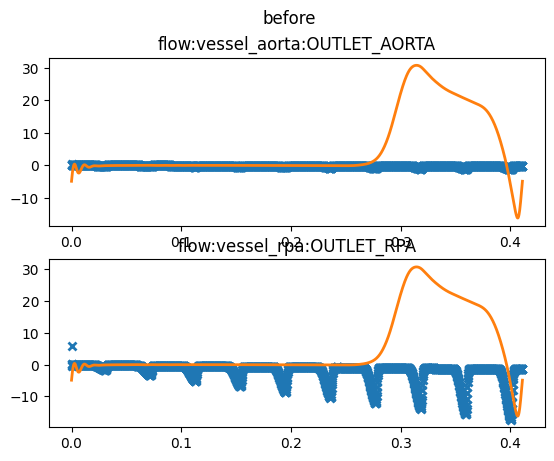

obj_val_1 =  2.3787970489937766


ValueError: target must be in OUTLET boundary condition or chamber

In [3]:
class optimizer_class():

    def __init__(self, 
                 fwd_sim_file, 
                 calibration_data_file, 
                 variables_to_opt, 
                 bounds_all,
                 cycle_duration=1.0,
                 maxit=1000,
                 plot_variables=None):

        with open(fwd_sim_file) as fname:
            self.fwd_sim_obj = json.load(fname)        

        with open(calibration_data_file) as fname:
            self.calibration_data = json.load(fname)                

        self.solver = pysvzerod.Solver(self.fwd_sim_obj)

        self.variables_to_opt = variables_to_opt

        if plot_variables is not None:
            self.plot_variables = plot_variables
        else:
            self.plot_variables = self.variables_to_opt

        self.solver_run = False

        self.cycle_duration = cycle_duration
        self.maxit = maxit

        # dictionary of all values used in optimization 
        self.values = {}
        for var_name in variables_to_opt:
            self.values[var_name] = None

        self.bounds_all = bounds_all



    def run_and_update(self):

        self.solver.run()
        for var_name in self.variables_to_opt:
            self.values[var_name] = np.array(self.solver.get_single_result(var_name))


    def objective_function(self):

        objective_value = 0.0

        for var_name in self.variables_to_opt:

            # time values for one cycle normalized for solver data 
            n_time_values = len(self.values[var_name])
            query_pts = np.linspace(0.0, self.cycle_duration, n_time_values)

            # time values for one cycle normalized for observation data 
            n_times_observation = len(self.calibration_data['y'][var_name])
            observation_pts = np.linspace(0.0, self.cycle_duration, n_times_observation)

            # linearly interpolated obs data
            data_interpolated = np.interp(query_pts, observation_pts, np.array(self.calibration_data['y'][var_name]))

            diffs = abs(self.values[var_name] - data_interpolated)
            # diffs = abs(self.values[var_name] - np.array(calibration_data_file['y'][var_name]))

            # no integration weights needed because cancel 
            diffs_two_norm_squared = (diffs ** 2).sum()
            data_two_norm_squared = (data_interpolated ** 2).sum() 

            rel_error = diffs_two_norm_squared / data_two_norm_squared

            objective_value += rel_error 

            # objective_value += (diffs ** 2).sum()

            # plot
            # fig, ax = plt.subplots()

            # ax.plot(query_pts, self.values[var_name], 'x', markeredgewidth=2)
            # ax.plot(query_pts, data_interpolated, linewidth=2.0)
            # plt.show()

        # print("objective_value = ", objective_value)

        return objective_value



    def plot(self, title_str=''):

        print("self.plot_variables = ", self.plot_variables)

        fig, axs = plt.subplots(len(self.plot_variables))
        fig.suptitle(title_str)

        for idx,var_name in enumerate(self.plot_variables):

            if "pressure" in var_name:
                scaling = 1.0/MMHG_TO_CGS
            else: 
                scaling = 1.0

            # time values for one cycle normalized for solver data 
            n_time_values = len(self.values[var_name])
            query_pts = np.linspace(0.0, self.cycle_duration, n_time_values)

            # time values for one cycle normalized for observation data 
            n_times_observation = len(self.calibration_data['y'][var_name])
            observation_pts = np.linspace(0.0, self.cycle_duration, n_times_observation)

            # linearly interpolated obs data
            data_interpolated = np.interp(query_pts, observation_pts, np.array(self.calibration_data['y'][var_name]))

            print(query_pts)
            print(scaling * self.values[var_name])
            
            axs[idx].plot(query_pts, scaling * self.values[var_name], 'x', markeredgewidth=2)
            axs[idx].plot(query_pts, scaling * data_interpolated, linewidth=2.0)            
            axs[idx].set_title(var_name)

        plt.show(block=False)


    def output_mat(self, matfile_name):

        times = self.solver.get_times()
        q_aorta = self.solver.get_single_result("flow:vessel:OUTLET")
        p_aorta = self.solver.get_single_result("pressure:vessel:OUTLET")

        q_mitral = self.solver.get_single_result("flow:valve0:ventricle")
        p_lv_in = self.solver.get_single_result("pressure:valve0:ventricle")

        q_lv_out = self.solver.get_single_result("flow:ventricle:valve1")
        p_lv_out = self.solver.get_single_result("pressure:ventricle:valve1")

        q_aortic_valve = self.solver.get_single_result("flow:valve1:vessel")
        p_aortic_valve = self.solver.get_single_result("pressure:valve1:vessel")

        pressure_c_outlet = self.solver.get_single_result("pressure_c:OUTLET")

        volume_lv = self.solver.get_single_result("Vc:ventricle")


        dic = {"times": times, 
               "q_aorta": q_aorta,
               "p_aorta": p_aorta,
               "q_mitral": q_mitral,
               "p_lv_in": p_lv_in,
               "q_lv_out": q_lv_out,
               "p_lv_out": p_lv_out,
               "q_aortic_valve": q_aortic_valve,
               "p_aortic_valve": p_aortic_valve,
               "pressure_c_outlet": pressure_c_outlet,
               "volume_lv": volume_lv
            }

        savemat("matfile_name", dic)


    def print_summary(self, targets):

        times = self.solver.get_times()
        p_aorta = self.solver.get_single_result("pressure:vessel:OUTLET")
        volume_lv = self.solver.get_single_result("Vc:ventricle")

        volume_lv_initial = volume_lv[0]
        print("volume_lv_initial = ", volume_lv_initial)

        for idx,t in enumerate(times):
            if t >= 0.25:
                print("at t = ", t, ", p_aortic_valve_mmHg = ", p_aorta[idx]/MMHG_TO_CGS)
                break 

        for target_name in targets:
            if target_name in self.fwd_sim_obj['chambers'][0]['values']:
                print(target_name, "= ", self.fwd_sim_obj['chambers'][0]['values'][target_name])
            elif target_name in self.fwd_sim_obj['boundary_conditions'][1]['bc_values']:
                print(target_name, "= ", self.fwd_sim_obj['boundary_conditions'][1]['bc_values'][target_name])



def objective_function_free_params(params, opt_instance, targets):

    # set new values & re-run 0d solver 
    for idx,target_name in enumerate(targets):
        if target_name in opt_instance.fwd_sim_obj['chambers'][0]['values']:
            opt_instance.fwd_sim_obj['chambers'][0]['values'][target_name] = params[idx]
        elif target_name in opt_instance.fwd_sim_obj['boundary_conditions'][1]['bc_values']:
            opt_instance.fwd_sim_obj['boundary_conditions'][1]['bc_values'][target_name] = params[idx]
        else: 
            raise ValueError("target must be in OUTLET boundary condition or chamber")

    opt_instance.solver = pysvzerod.Solver(opt_instance.fwd_sim_obj)

    try:
        opt_instance.run_and_update()
    except RuntimeError:
        return float('inf')

    return opt_instance.objective_function()    


def run_optimization(opt_instance, targets):

    x0 = []
    bounds = []    
    for idx,target_name in enumerate(targets):

        if target_name in opt_instance.fwd_sim_obj['chambers'][0]['values']:
            x0.append(opt_instance.fwd_sim_obj['chambers'][0]['values'][target_name])

        elif target_name in opt_instance.fwd_sim_obj['boundary_conditions'][1]['bc_values']:
            x0.append(opt_instance.fwd_sim_obj['boundary_conditions'][1]['bc_values'][target_name])
            # only work on outlet bc 
            assert opt_instance.fwd_sim_obj['boundary_conditions'][1]['bc_name'] == 'OUTLET'
        else: 
            raise ValueError("target must be in OUTLET boundary condition or chamber")

        bounds.append(opt_instance.bounds_all[target_name])

    result = minimize(objective_function_free_params, 
                      x0, 
                      args=(opt_instance, targets), 
                      bounds = bounds,
                      method='Nelder-Mead',
                      options={'maxiter': opt_instance.maxit}
                      )

    return result


    
if __name__== "__main__":

    run_opt = True
    if run_opt:

        cycle_duration = 0.411
        maxit = 1000000

        fwd_sim_file = "config_preop.json"

        calibration_data_file = "calibration_preop.json"

        var_to_opt = ["flow:vessel_aorta:OUTLET_AORTA","flow:vessel_rpa:OUTLET_RPA"]    
        plot_vars = ["flow:vessel_aorta:OUTLET_AORTA","flow:vessel_rpa:OUTLET_RPA"]    

        targets_all = ['Emax', 'Emin', 't_shift', 'tau_1', 'tau_2', 'm1', 'm2', 'C', 'Rd', 'Rp']

        bounds_all = {'Emax'    : [0.0, 1e5], 
                      'Emin'    : [0.0, 1e4], 
                      't_shift' : [0.0, cycle_duration], 
                      'tau_1'   : [0.0, cycle_duration], 
                      'tau_2'   : [0.0, cycle_duration], 
                      'm1'      : [0.0, 100.0], 
                      'm2'      : [0.0, 100.0],
                      'C'       : [0.0, 0.01],
                      'Rd'      : [0.0, 100000.0],
                      'Rp'      : [0.0, 5000.0]
                      }



        optimizer = optimizer_class(fwd_sim_file, 
                                    calibration_data_file, 
                                    var_to_opt, 
                                    bounds_all,
                                    cycle_duration, 
                                    maxit,
                                    plot_vars)


        optimizer.run_and_update()
        obj_val_1 = optimizer.objective_function()

        
        
        optimizer.plot('before')
        print("obj_val_1 = ", obj_val_1)

        targets = ['C', 'Rd', 'Rp']
        optimizer.variables_to_opt = ["flow:vessel_aorta:OUTLET_AORTA", "flow:vessel_rpa:OUTLET_rpa"]    
        result = run_optimization(optimizer, targets)    
        print("result = ", result)    
        optimizer.print_summary(targets_all)        
        optimizer.plot('after rcr')

        optimizer.plot('after')

        optimizer.output_mat("chamber_elastance_two_hill_valve_rcr_optimized_results.mat")

        plt.show()


In [ ]:
data_interpolated